# Heston — Method Comparison

| Method | Trainer | Notes |
|---|---|---|
| **Delta LSMC** | — | Regression-based delta baseline |
| **Delta CF** | — | Exact Heston delta (slow) |
| **DH** | DeepHedging | Plain MLP |
| **DH-PAF** | DeepHedging | PAF embedding |
| **DH-PnL** | DeepHedging | MLP + running P&L feature |
| **DH-PAF-PnL** | DeepHedging | PAF + P&L |
| **DH-SAC** | SAC | Entropy regularisation |

## 0. Setup

In [1]:
import os

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.samplers      import GBMSampler
from src.metrics       import SoftMin
from src.backtest      import torch_backtest
from src.models        import ModelConfig
from src.trainers      import (TrainerConfig, DeepHedgingTrainer, SACTrainer,
                               DeviationTrainer)
from src.deltas        import BSMDeltaHedger
from src.logging_utils import save_log

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cpu


## 1. Parameters

In [2]:
# ── market ────────────────────────────────────────────────
S0    = 100.0
r     = 0.1
sigma = 0.2
T     = 1.0
N     = 30
K     = 100.0
cost  = 1e-3
a     = 1.0

# ── training ──────────────────────────────────────────────
M_train  = 3_000
M_val    = 5_000   # validation paths (used for early stopping & best model)
M_test   = 5_000   # held-out test paths (evaluated once at the end)
n_epochs = 10_000
log_every           = 200
early_stop_patience = 100  # val checks without improvement → stop
lr                  = 1e-3

RESULTS_DIR = 'results_gbm'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── paths ─────────────────────────────────────────────────
sampler = GBMSampler(
    S0=S0, r=r, sigma=sigma, T=T, N=N
)

np.random.seed(42)
paths_val    = sampler.sample(M_val)
paths_test   = sampler.sample(M_test)
paths_val_t  = torch.tensor(paths_val,  dtype=torch.float32, device=DEVICE)
paths_test_t = torch.tensor(paths_test, dtype=torch.float32, device=DEVICE)

results = {}  # name -> {pnl, fees, log}

## 2. Helpers

In [3]:
def softmin_np(pnl: np.ndarray, a: float = a) -> float:
    return float(np.log(np.exp(-a * pnl).mean()) / a)


def record(name: str, pnl: np.ndarray, fees: np.ndarray, log: list = []):
    results[name] = {'pnl': pnl, 'fees': fees, 'log': log}
    print(f"  {name:<22}  SoftMin={softmin_np(pnl):>8.4f}  "
          f"mean={pnl.mean():>7.4f}  std={pnl.std():>6.4f}")
    # сохраняем всегда, для baseline пишем одну запись с финальным результатом
    summary = [{"epoch": 0, "val_loss": softmin_np(pnl),
                "elapsed": 0.0, "mean_pnl": float(pnl.mean()),
                "std_pnl": float(pnl.std())}] if not log else log
    save_log(summary, os.path.join(RESULTS_DIR, name.replace(' ', '_')))


def run_trainer(trainer, name: str):
    log       = trainer.fit()
    pnl, fees = trainer.eval_on_test()
    record(name, pnl, fees, log)

def base_cfg(**overrides) -> TrainerConfig:
    """TrainerConfig with shared defaults."""
    defaults = dict(
        n_epochs=n_epochs, M_train=M_train,
        log_every=log_every,
        early_stop_patience=early_stop_patience,
        lr=lr,
    )
    return TrainerConfig(**{**defaults, **overrides})


def make_trainer(TrainerClass, cfg, **kwargs):
    return TrainerClass(
        cfg=cfg,
        sampler=sampler,
        paths_val_t=paths_val_t,
        paths_test_t=paths_test_t,
        device=DEVICE,
        risk_aversion=a,
        K=K,
        cost=cost,
        **kwargs
    )


print('Helpers ready.')

Helpers ready.


## 3. Delta Formula

In [6]:
bsm = BSMDeltaHedger(K=K, r=r, sigma=sigma, T=T, N=N)
paths_test_t = torch.tensor(paths_test, dtype=torch.float32)
pnl, fees = torch_backtest(paths_test_t, delta_exogenous=bsm, K=K, detach=True)
record('Delta BSM', pnl, fees)

  Delta BSM               SoftMin= 10.1621  mean=-7.0091  std=2.4432


## 5. DH — plain MLP

In [6]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='mlp'))),
    'DH'
)

  0%|          | 0/10000 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (3000x4 and 3x64)

## 6. DH-PAF

In [4]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='paf'))),
    'DH-PAF'
)

Trainable parameters: 4,273


100%|██████████| 10000/10000 [33:40<00:00,  4.95it/s]

  DH-PAF                  SoftMin=  9.0032  mean=-7.9262  std=1.4343


## 7. DH-PnL

In [ ]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='mlp'), use_pnl=True)),
    'DH-PnL'
)

  DH-PnL                  SoftMin=  9.7047  mean=-8.0963  std=2.0591


## 8. DH-PAF-PnL

In [ ]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='paf'), use_pnl=True)),
    'DH-PAF-PnL'
)

  DH-PAF-PnL              SoftMin= 29.5465  mean=-8.4143  std=6.7998


## 9. DH-SAC

In [ ]:
run_trainer(
    make_trainer(SACTrainer,
                 base_cfg(model=ModelConfig(arch='paf'),
                          beta_start=0.05, beta_end=0.001)),
    'DH-SAC'
)

  DH-SAC                  SoftMin=  9.2132  mean=-8.1198  std=1.5900


# 10. DH-PAF-PnL Pretrain Without PnL

In [ ]:
run_trainer(
    make_trainer(DeepHedgingTrainer,
                 base_cfg(model=ModelConfig(arch='paf'), use_pnl=True, pnl_start_epoch = 2000)),
    'DH-PAF-PnL-Pretrain'
)

100%|██████████| 10000/10000 [1:02:07<00:00,  2.68it/s]

  DH-PAF-PnL-Pretrain     SoftMin= 30.5461  mean=-8.0647  std=5.9958


# 11. Delta Deviation Runner

In [ ]:

# Heston (sigma_const=None → берём sqrt(v_t))
run_trainer(
    DeviationTrainer(
        cfg          = base_cfg(model=ModelConfig(arch='paf',
                                                  zero_last_layer=True),
                                use_pnl=True),
        sampler      = sampler,
        paths_val_t  = paths_val_t,
        paths_test_t = paths_test_t,
        device       = DEVICE,
        risk_aversion = a, K = K, cost = cost,
        r            = r,
        sigma_const  = sigma
    ),
    'DH-Deviation'
)

 10%|█         | 1026/10000 [04:42<46:09,  3.24it/s] 

## 12. Summary table

In [ ]:
print(f"\n{'Method':<24} {'SoftMin':>10} {'PnL mean':>10} {'PnL std':>9} {'Fees mean':>10}")
print('─' * 68)
for name, res in results.items():
    pnl, fees = res['pnl'], res['fees']
    print(f"{name:<24} {softmin_np(pnl):>10.4f} {pnl.mean():>10.4f} "
          f"{pnl.std():>9.4f} {fees.mean():>10.4f}")


Method                      SoftMin   PnL mean   PnL std  Fees mean
────────────────────────────────────────────────────────────────────
PPO                         67.6596    -8.3935   11.8648     0.1041


## 13. Learning curves

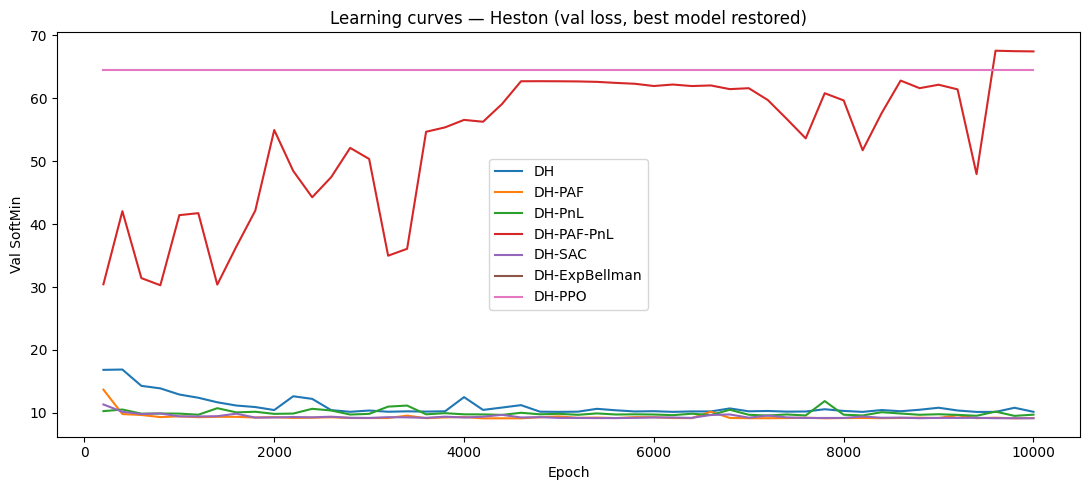

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    log = res.get('log', [])
    if not log:
        continue
    ax.plot([e['epoch']    for e in log],
            [e['val_loss'] for e in log], label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val SoftMin')
ax.set_title('Learning curves — Heston (val loss, best model restored)')
ax.legend()
plt.tight_layout()
plt.show()

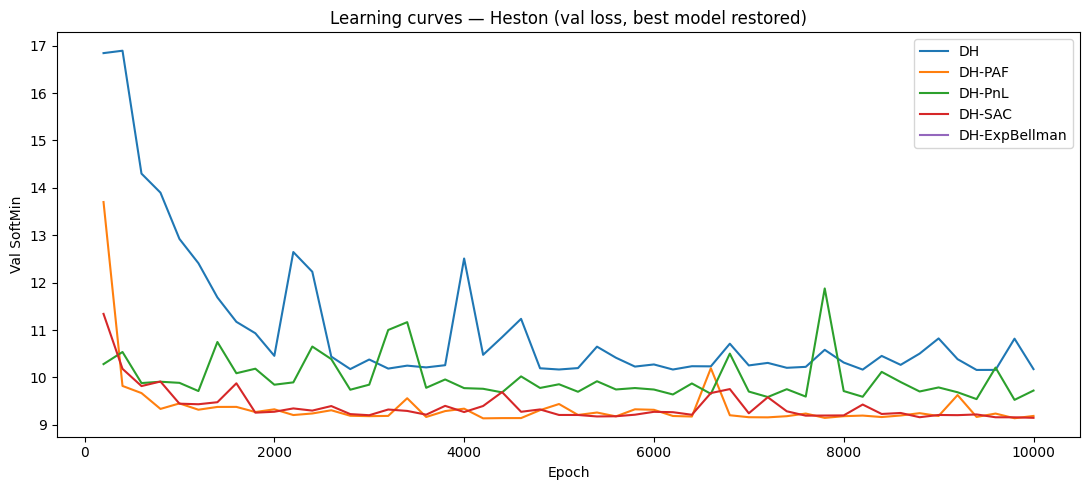

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
for name, res in results.items():
    if name in ['DH-PAF-PnL', 'DH-PPO']:
        continue
    log = res.get('log', [])
    if not log:
        continue
    ax.plot([e['epoch']    for e in log],
            [e['val_loss'] for e in log], label=name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val SoftMin')
ax.set_title('Learning curves — Heston (val loss, best model restored)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
results['DH-ExpBellman']

{'pnl': array([ -9.756611 , -12.964827 ,   1.889287 , ..., -14.284426 ,
         -4.643322 ,  -1.6474743], shape=(5000,), dtype=float32),
 'fees': array([0.13045558, 0.15329853, 0.12018931, ..., 0.10399057, 0.12469694,
        0.20827378], shape=(5000,), dtype=float32),
 'log': [{'epoch': 200, 'val_loss': nan, 'elapsed': 72.36504304199843},
  {'epoch': 400, 'val_loss': nan, 'elapsed': 144.99919474999842},
  {'epoch': 600, 'val_loss': nan, 'elapsed': 213.28767900199819},
  {'epoch': 800, 'val_loss': nan, 'elapsed': 288.1879537959976},
  {'epoch': 1000, 'val_loss': nan, 'elapsed': 360.31721928499974},
  {'epoch': 1200, 'val_loss': nan, 'elapsed': 428.70395605999875},
  {'epoch': 1400, 'val_loss': nan, 'elapsed': 497.1369278059974},
  {'epoch': 1600, 'val_loss': nan, 'elapsed': 572.6649390700004},
  {'epoch': 1800, 'val_loss': nan, 'elapsed': 644.595522145999},
  {'epoch': 2000, 'val_loss': nan, 'elapsed': 724.0908153109995},
  {'epoch': 2200, 'val_loss': nan, 'elapsed': 796.1834424519984

## 14. PnL distributions

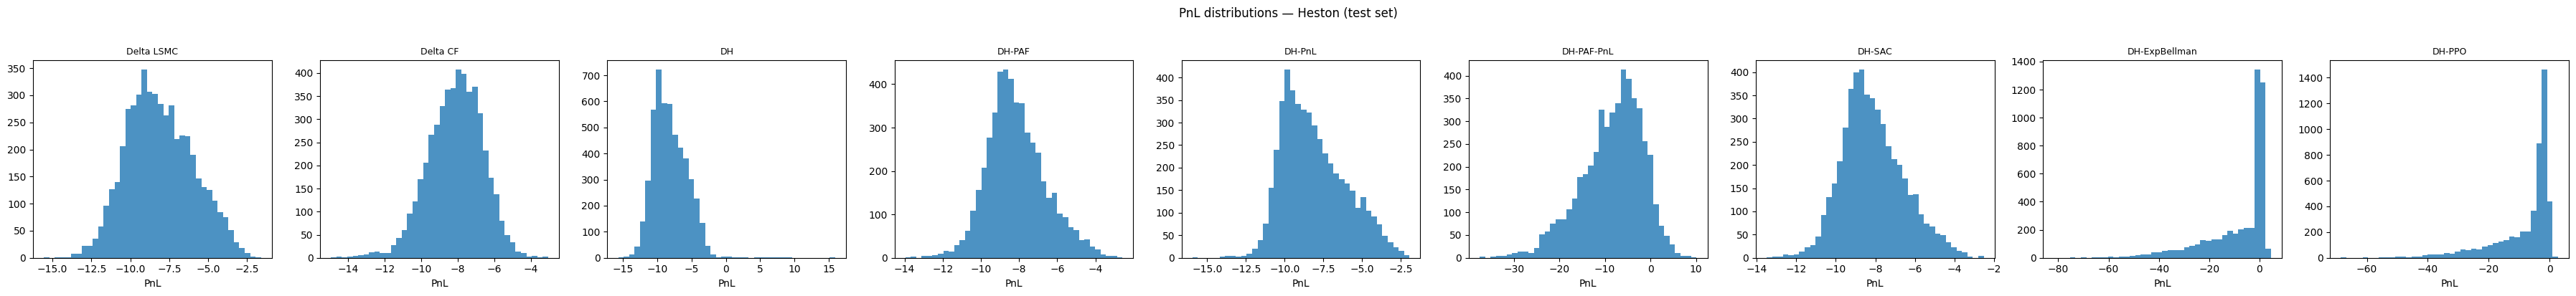

In [ ]:
names = list(results.keys())
fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 4))
if len(names) == 1:
    axes = [axes]
for ax, name in zip(axes, names):
    ax.hist(results[name]['pnl'], bins=40, alpha=0.8, edgecolor='none')
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('PnL')
plt.suptitle('PnL distributions — Heston (test set)', y=1.02)
plt.tight_layout()
plt.show()